SleepGuard: Predictive Analytics for Sleep Apnea Detection

---
### Table of Contents
1. [Imports & Setup](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Cleaning & Preprocessing](#4)
5. [Association Rule Mining (Apriori)](#5)
6. [Model Training: Neural Network (MLP)](#6)
7. [Model Training: Logistic Regression](#7)
8. [Model Training: Gradient Boosting](#8)
9. [Model Evaluation & Comparison](#9)

---
## 1. Imports & Setup <a id='1'></a>

In [134]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import combinations
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

DATA_PATH = 'Sleep Apnea Dataset.csv'

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load Dataset <a id='2'></a>

In [135]:
df_raw = pd.read_csv(DATA_PATH, keep_default_na=False)

print(f"Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df_raw.dtypes.to_string())

Dataset shape: 374 rows x 13 columns

Column dtypes:
Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str


In [136]:
print("First 5 rows:")
df_raw.head()

First 5 rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [137]:
print("Missing values per column:")
print(df_raw.isnull().sum().to_string())

print("\nBasic statistics (numeric columns):")
df_raw.describe()

Missing values per column:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0

Basic statistics (numeric columns):


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [138]:
print("--- Unique values for key categorical columns ---")
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    print(f"\n{col} ({df_raw[col].nunique()} unique):")
    print(df_raw[col].value_counts().to_string())

dup_ids = df_raw['Person ID'].duplicated().sum()
print(f"\nDuplicate Person IDs: {dup_ids}")

--- Unique values for key categorical columns ---

Gender (2 unique):
Gender
Male      189
Female    185

Occupation (11 unique):
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1

BMI Category (4 unique):
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10

Sleep Disorder (3 unique):
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77

Duplicate Person IDs: 0


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

In [139]:
# Create binary subset (exclude Insomnia) for EDA visualisations
df_binary = df_raw[df_raw['Sleep Disorder'] != 'Insomnia'].copy()
print(f"Binary subset size: {len(df_binary)} rows")
print(df_binary['Sleep Disorder'].value_counts())

Binary subset size: 297 rows
Sleep Disorder
None           219
Sleep Apnea     78
Name: count, dtype: int64


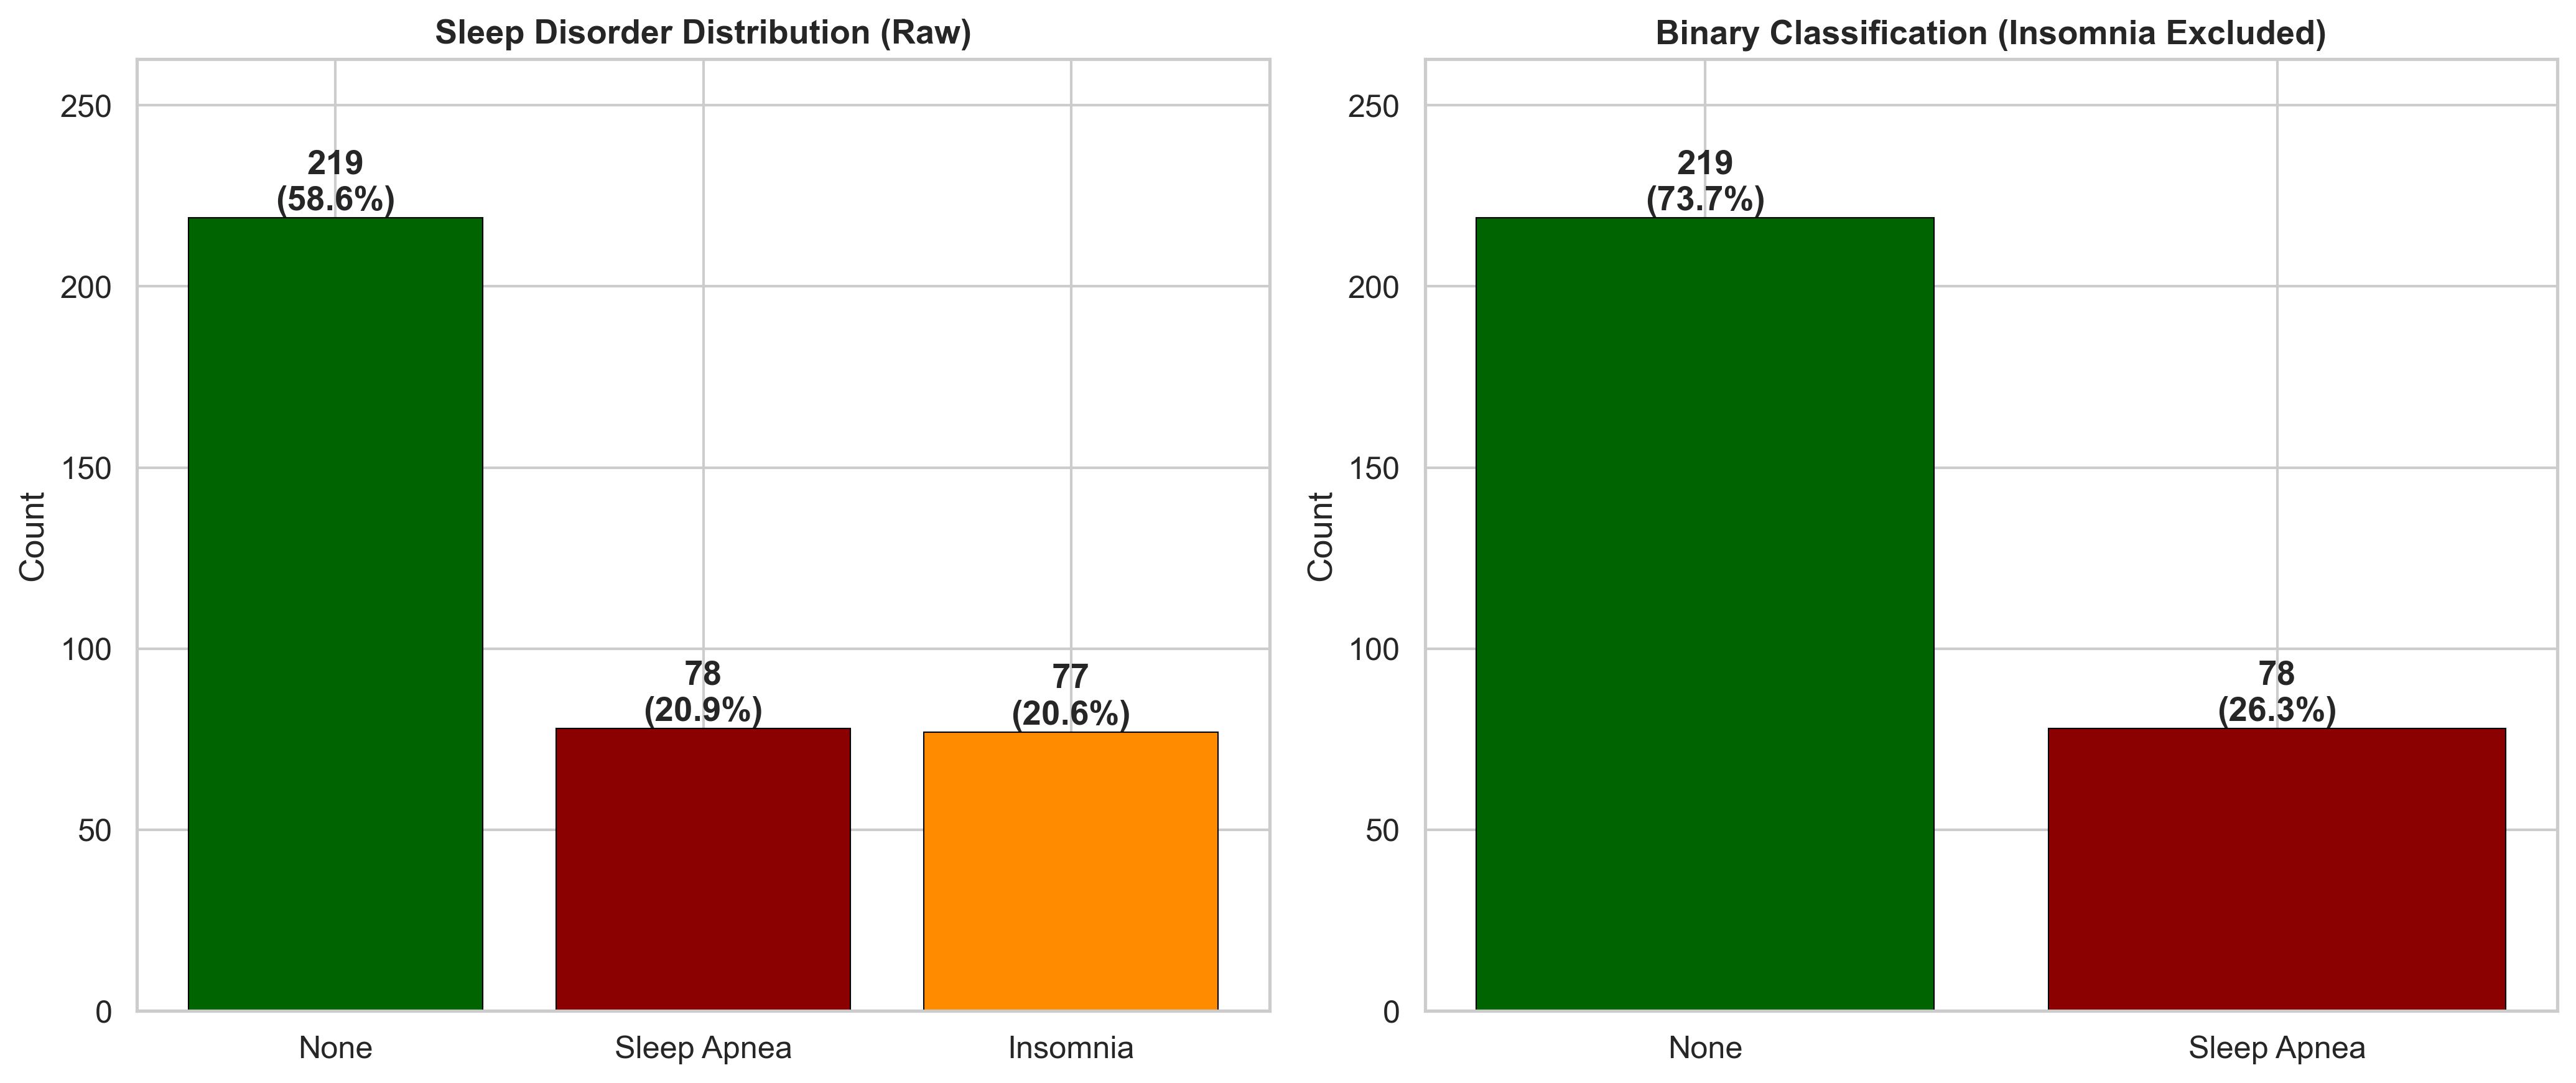

In [140]:
# Figure 1: Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi = 300)

disorder_counts = df_raw['Sleep Disorder'].value_counts()
colors_raw = ['darkgreen', 'darkred', 'darkorange']
axes[0].bar(disorder_counts.index, disorder_counts.values, color=colors_raw,
            edgecolor='black', linewidth=0.5)
for i, (val, cnt) in enumerate(zip(disorder_counts.index, disorder_counts.values)):
    axes[0].text(i, cnt + 2, f'{cnt}\n({cnt/len(df_raw)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Sleep Disorder Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(disorder_counts.values) * 1.2)

binary_counts = df_binary['Sleep Disorder'].value_counts()
colors_bin = ['darkgreen', 'darkred']
axes[1].bar(binary_counts.index, binary_counts.values, color=colors_bin,
            edgecolor='black', linewidth=0.5)
for i, (val, cnt) in enumerate(zip(binary_counts.index, binary_counts.values)):
    axes[1].text(i, cnt + 2, f'{cnt}\n({cnt/len(df_binary)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Binary Classification (Insomnia Excluded)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(binary_counts.values) * 1.2)

plt.tight_layout()
plt.show()

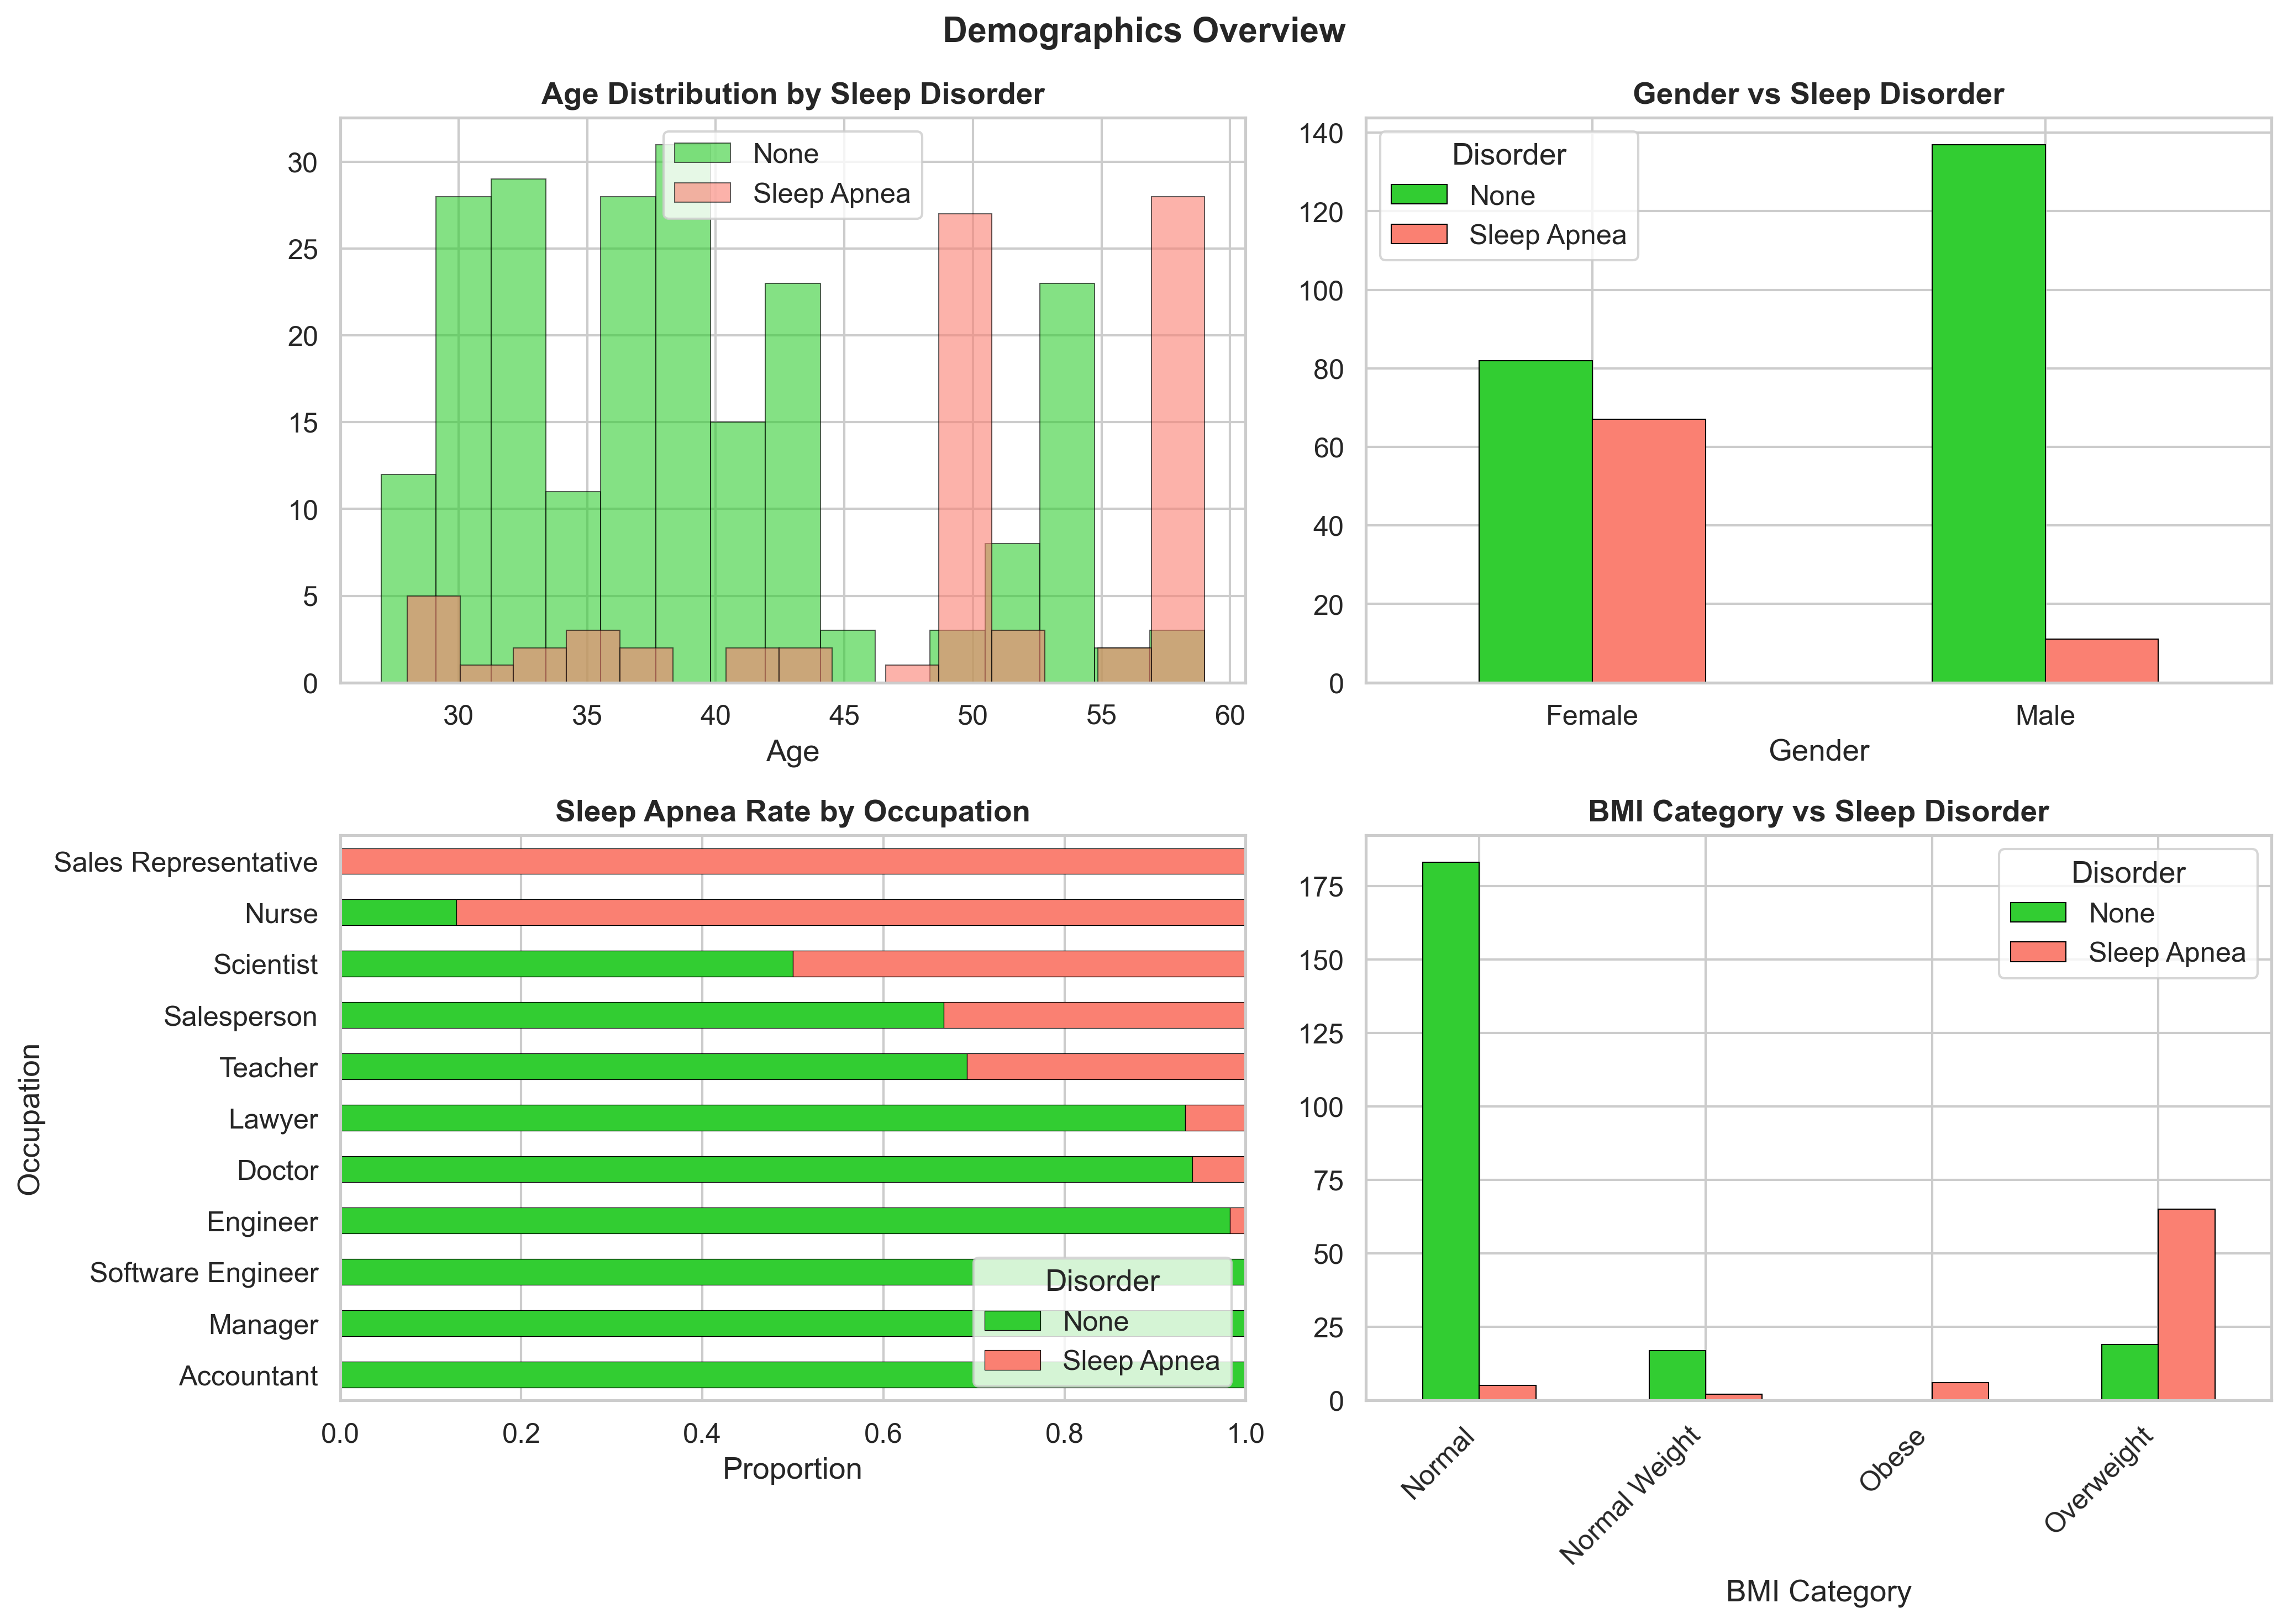

In [141]:
# Figure 2: Demographics
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi = 300)

for disorder, color in zip(['None', 'Sleep Apnea'], ['limegreen', 'salmon']):
    subset = df_binary[df_binary['Sleep Disorder'] == disorder]
    axes[0, 0].hist(subset['Age'], bins=15, alpha=0.6, label=disorder,
                    color=color, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Age Distribution by Sleep Disorder', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

gender_disorder = pd.crosstab(df_binary['Gender'], df_binary['Sleep Disorder'])
gender_disorder.plot(kind='bar', ax=axes[0, 1], color=['limegreen', 'salmon'],
                     edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Gender vs Sleep Disorder', fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].legend(title='Disorder')

occ_disorder = pd.crosstab(df_binary['Occupation'], df_binary['Sleep Disorder'])
occ_disorder_pct = occ_disorder.div(occ_disorder.sum(axis=1), axis=0)
occ_disorder_pct.sort_values('Sleep Apnea', ascending=True).plot(
    kind='barh', stacked=True, ax=axes[1, 0], color=['limegreen', 'salmon'],
    edgecolor='black', linewidth=0.3)
axes[1, 0].set_title('Sleep Apnea Rate by Occupation', fontweight='bold')
axes[1, 0].set_xlabel('Proportion')
axes[1, 0].legend(title='Disorder', loc='lower right')

bmi_disorder = pd.crosstab(df_binary['BMI Category'], df_binary['Sleep Disorder'])
bmi_disorder.plot(kind='bar', ax=axes[1, 1], color=['limegreen', 'salmon'],
                  edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('BMI Category vs Sleep Disorder', fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].legend(title='Disorder')

plt.suptitle('Demographics Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

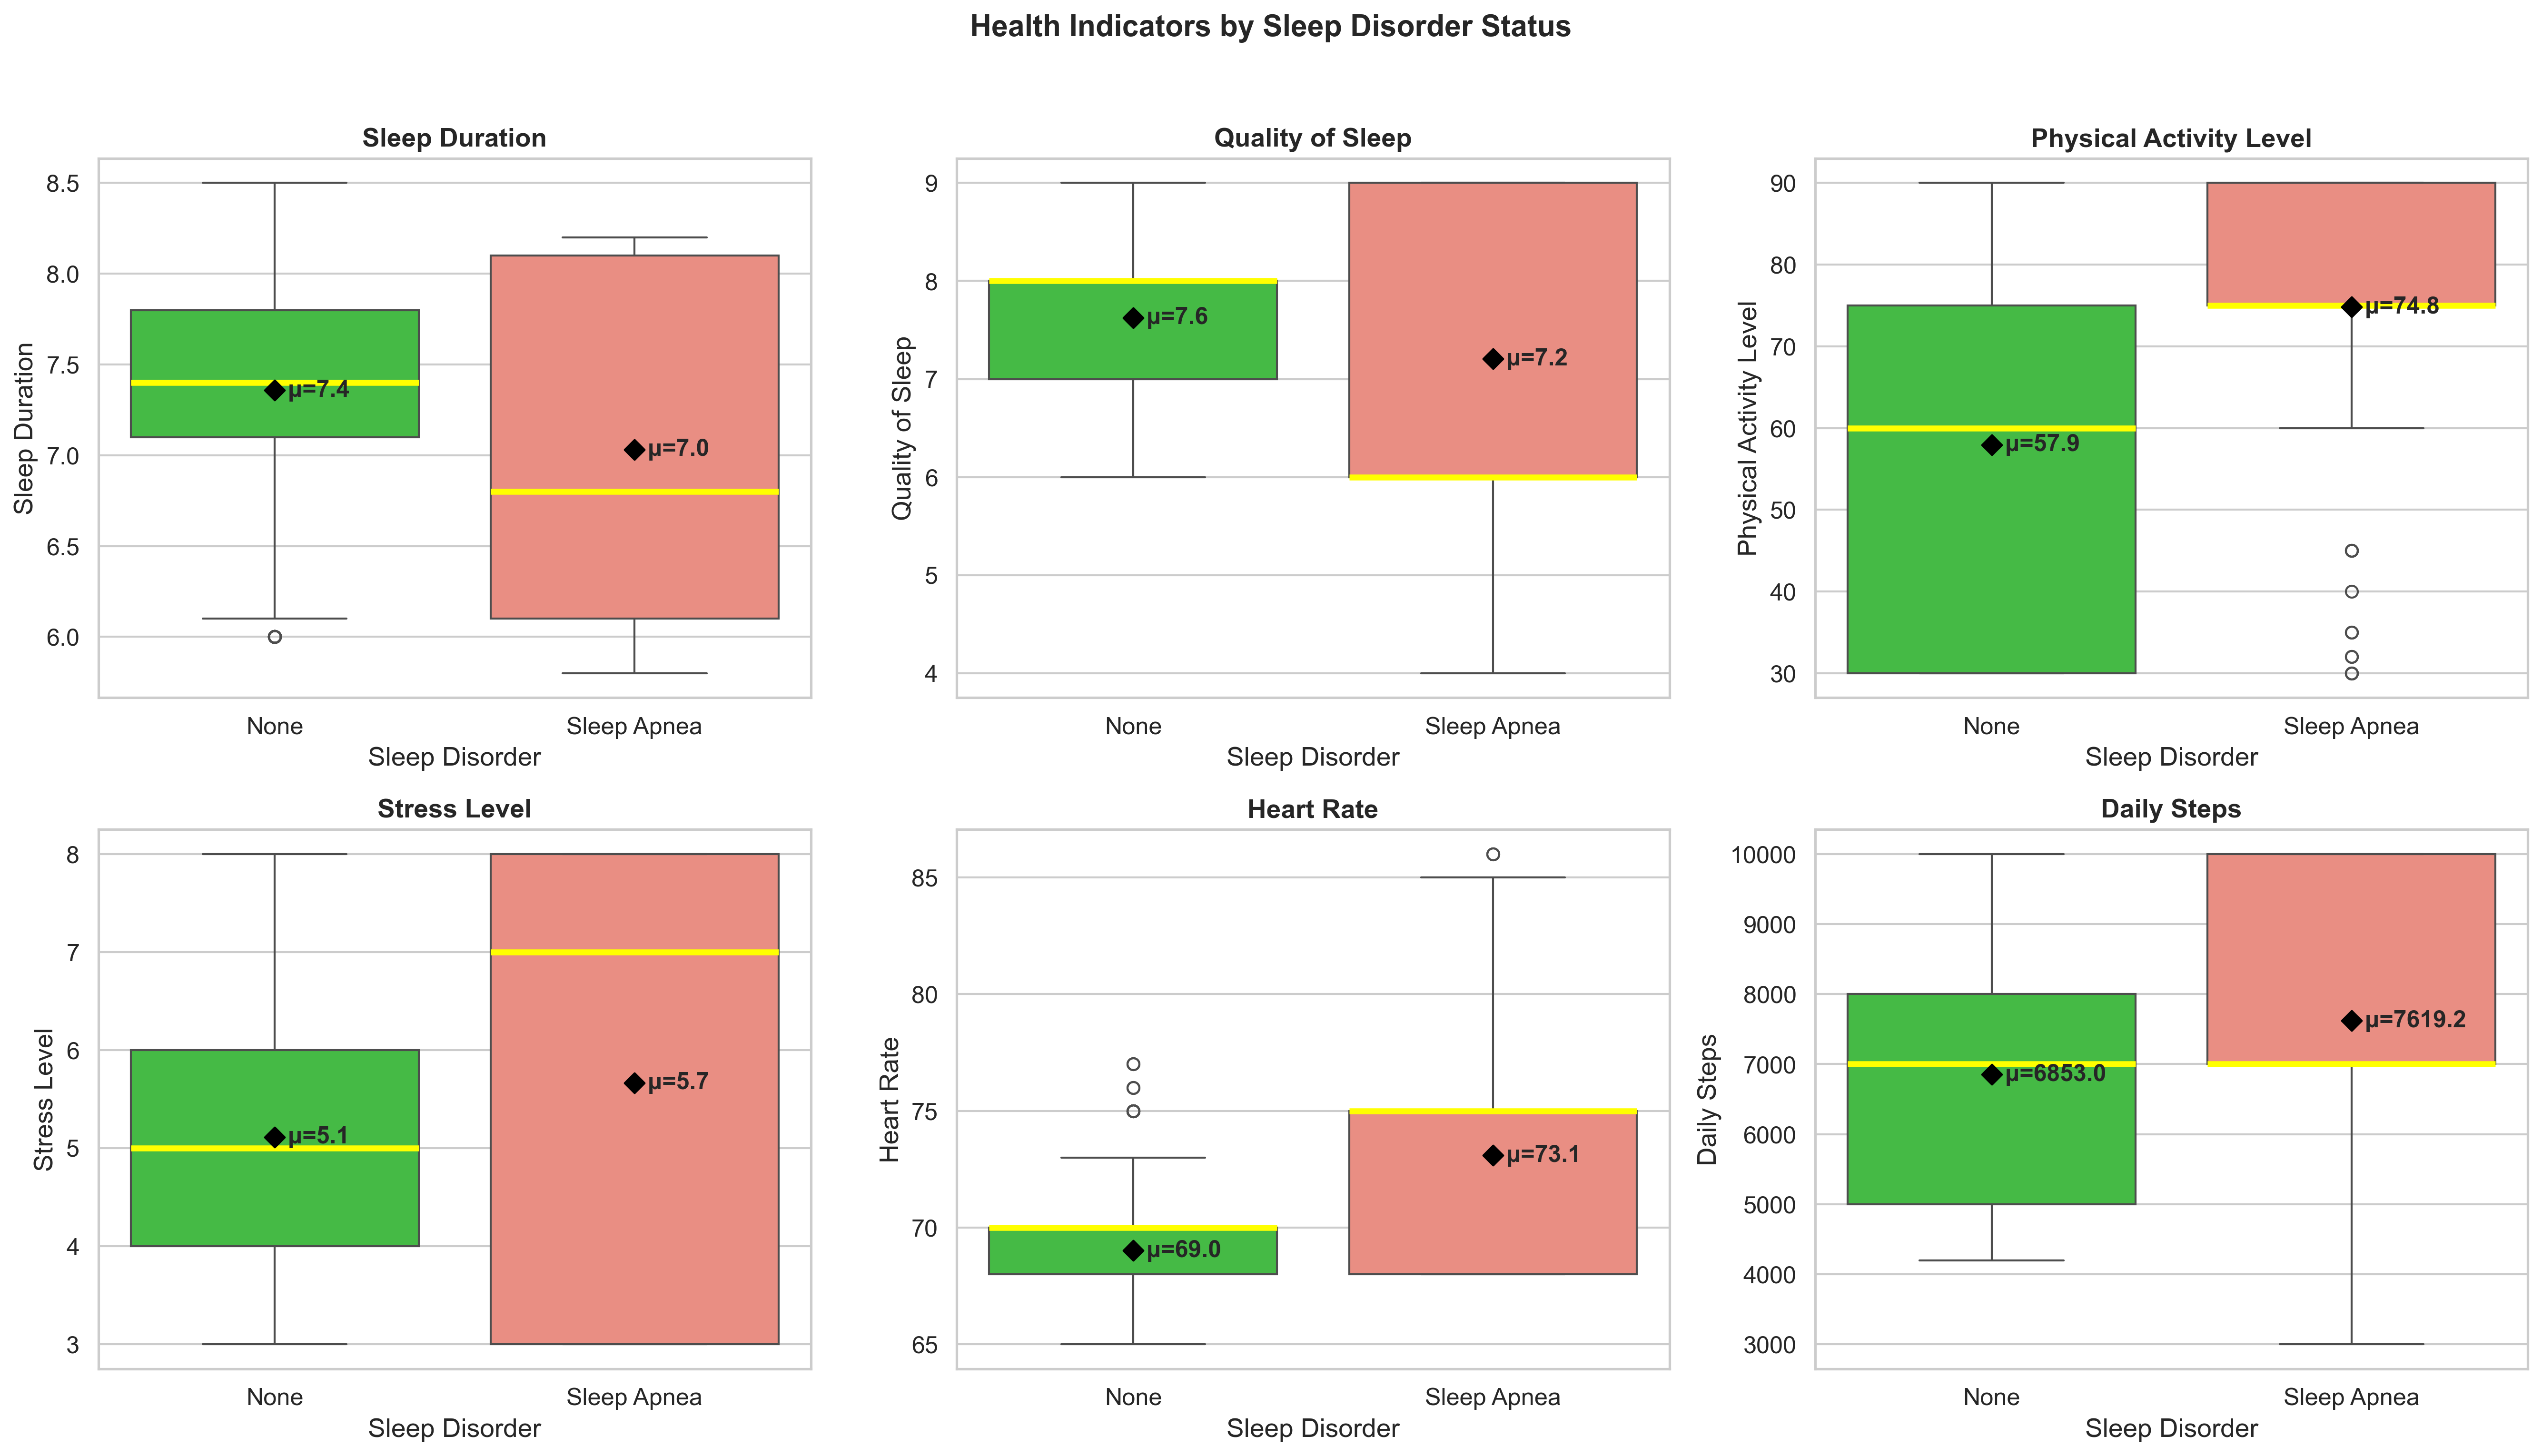

In [142]:
# Figure 3: Key health indicators boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi = 300)
health_vars = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
               'Stress Level', 'Heart Rate', 'Daily Steps']

for i, var in enumerate(health_vars):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_binary, x='Sleep Disorder', y=var, ax=ax,
                palette={'None': 'limegreen', 'Sleep Apnea': 'salmon'},
                hue='Sleep Disorder', legend=False,
                medianprops=dict(color='yellow', linewidth=3))
    ax.set_title(f'{var}', fontweight='bold')
    means = df_binary.groupby('Sleep Disorder')[var].mean()
    for j, (cat, mean_val) in enumerate(means.items()):
        ax.scatter(j, mean_val, color='black', marker='D', s=50, zorder=5)
        ax.text(j, mean_val, f'  μ={mean_val:.1f}', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Health Indicators by Sleep Disorder Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

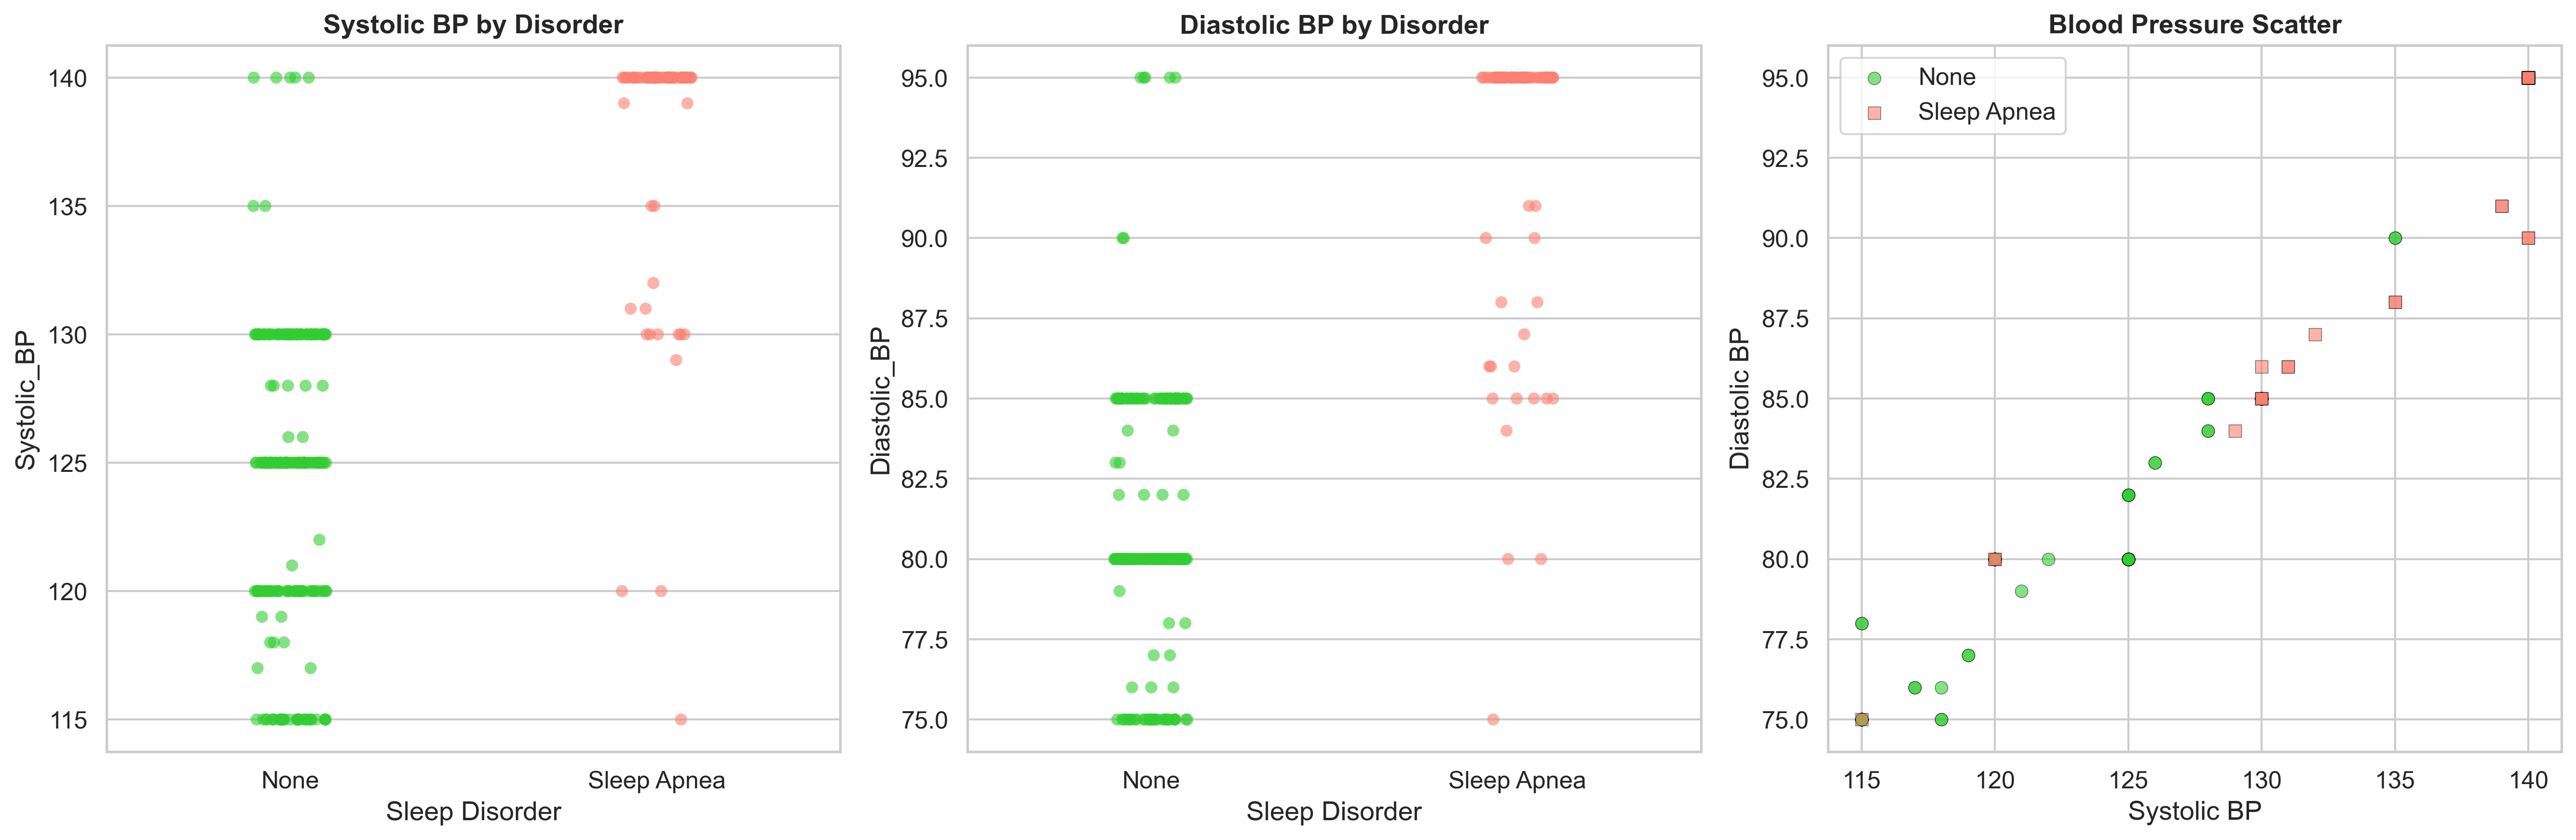

In [143]:
# Figure 4: Blood pressure analysis
df_binary_bp = df_binary.copy()
df_binary_bp[['Systolic_BP', 'Diastolic_BP']] = (
    df_binary_bp['Blood Pressure'].str.split('/', expand=True).astype(int)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi = 300)

sns.stripplot(data=df_binary_bp, x='Sleep Disorder', y='Systolic_BP', ax=axes[0],
              palette={'None': 'limegreen', 'Sleep Apnea': 'salmon'},
              hue='Sleep Disorder', legend=False, jitter=True, alpha=0.6, size=6)
axes[0].set_title('Systolic BP by Disorder', fontweight='bold')

sns.stripplot(data=df_binary_bp, x='Sleep Disorder', y='Diastolic_BP', ax=axes[1],
              palette={'None': 'limegreen', 'Sleep Apnea': 'salmon'},
              hue='Sleep Disorder', legend=False, jitter=True, alpha=0.6, size=6)
axes[1].set_title('Diastolic BP by Disorder', fontweight='bold')

for disorder, color, marker in zip(['None', 'Sleep Apnea'], ['limegreen', 'salmon'], ['o', 's']):
    subset = df_binary_bp[df_binary_bp['Sleep Disorder'] == disorder]
    axes[2].scatter(subset['Systolic_BP'], subset['Diastolic_BP'],
                    c=color, label=disorder, alpha=0.6, s=40,
                    marker=marker, edgecolors='black', linewidth=0.3)
axes[2].set_xlabel('Systolic BP')
axes[2].set_ylabel('Diastolic BP')
axes[2].set_title('Blood Pressure Scatter', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

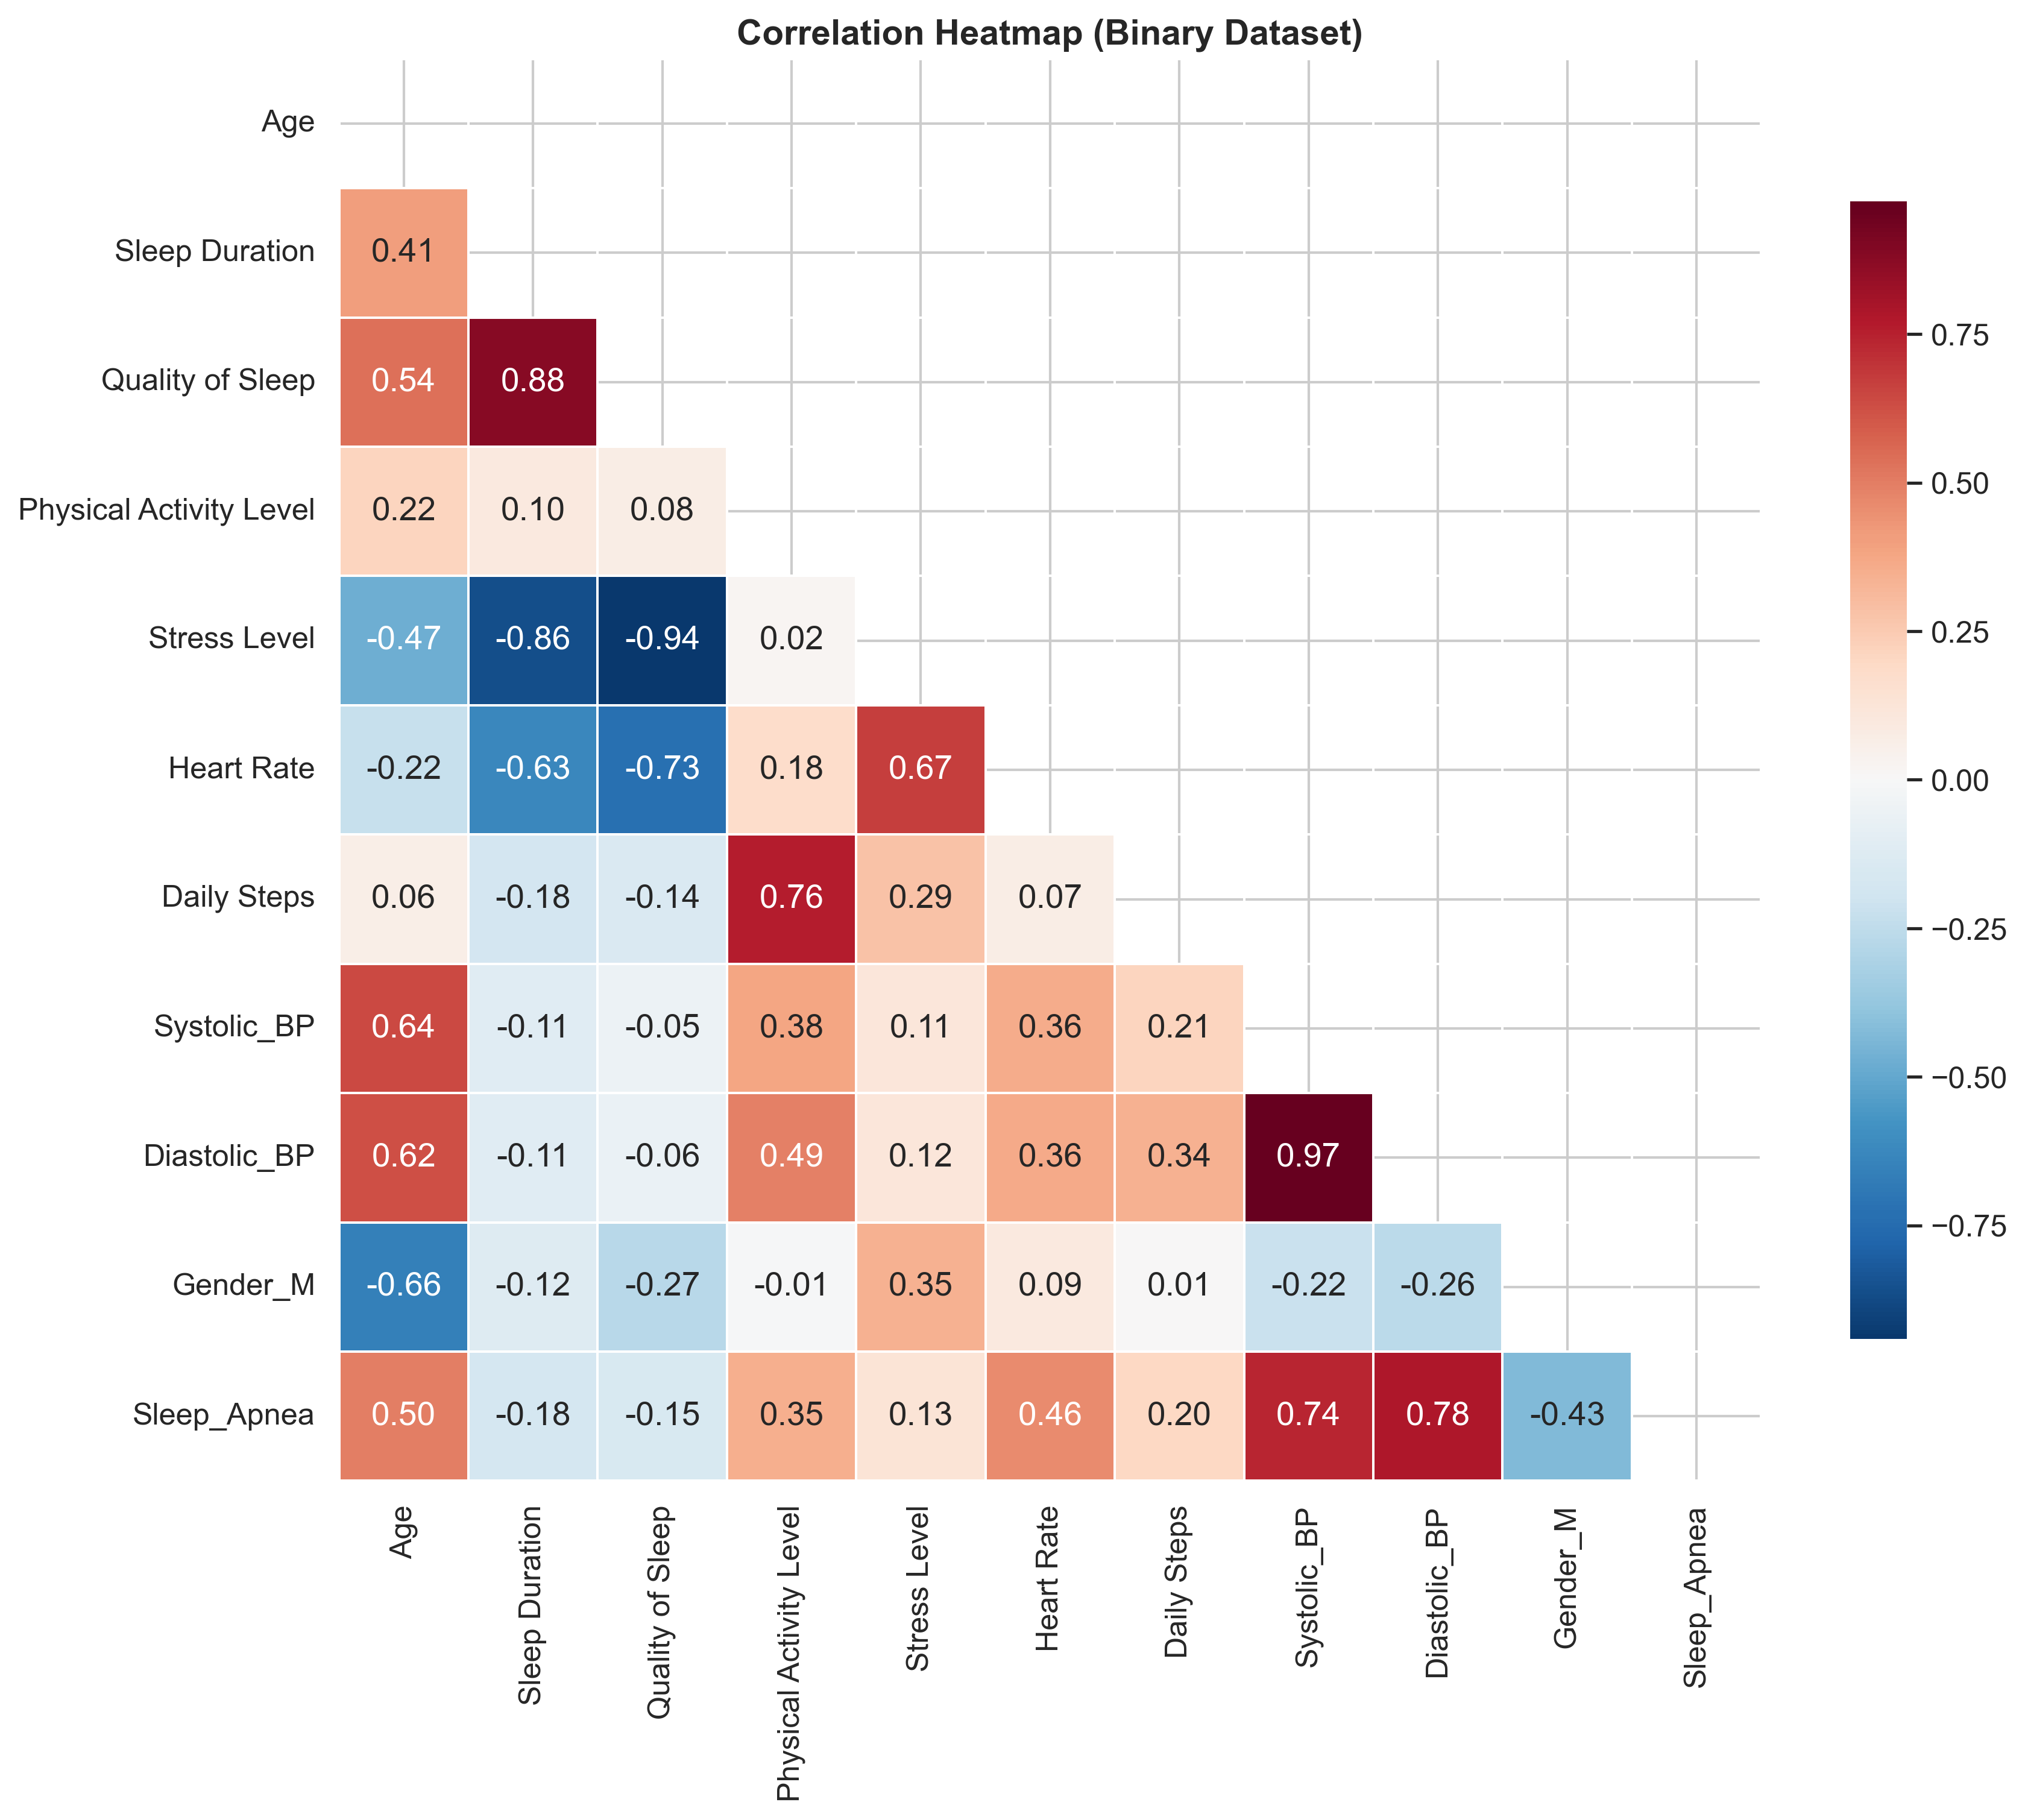


Correlation with Sleep Apnea (absolute value, descending):
Diastolic_BP               0.781792
Systolic_BP                0.735251
Age                        0.500545
Heart Rate                 0.459799
Gender_M                   0.426461
Physical Activity Level    0.345701
Daily Steps                0.203054
Sleep Duration             0.176716
Quality of Sleep           0.154454
Stress Level               0.133237


In [144]:
# Figure 5: Correlation heatmap
df_corr = df_binary_bp.copy()
df_corr['Sleep_Apnea'] = (df_corr['Sleep Disorder'] == 'Sleep Apnea').astype(int)
df_corr['Gender_M']    = (df_corr['Gender'] == 'Male').astype(int)

numeric_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP',
                'Gender_M', 'Sleep_Apnea']

fig, ax = plt.subplots(figsize=(12, 10), dpi = 300)
corr_matrix = df_corr[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Binary Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Sleep Apnea (absolute value, descending):")
corr_with_target = corr_matrix['Sleep_Apnea'].drop('Sleep_Apnea').abs().sort_values(ascending=False)
print(corr_with_target.to_string())

---
## 4. Data Cleaning & Preprocessing <a id='4'></a>

In [145]:
df = df_raw.copy()

# Drop Insomnia — binary classification only
n_before = len(df)
df = df[df['Sleep Disorder'] != 'Insomnia'].copy()
print(f"Removed Insomnia cases: {n_before} → {len(df)} rows")

# Binary target
df['Sleep_Apnea'] = (df['Sleep Disorder'] == 'Sleep Apnea').astype(int)
print(f"\nTarget distribution:\n{df['Sleep_Apnea'].value_counts().to_string()}")

# Combined BMI Normal Weight and Normal
print(f"\nBMI Category before fix: {df['BMI Category'].unique()}")
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})
print(f"BMI Category after fix:  {df['BMI Category'].unique()}")

# Split Blood Pressure into systolic / diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

#  Flag abnormal BP 
df['BP_Abnormal'] = ((df['Systolic_BP'] >= 130) | (df['Diastolic_BP'] >= 80)).astype(int)
print(f"\nBP_Abnormal distribution:\n{df['BP_Abnormal'].value_counts().to_string()}")

# Drop columns no longer needed
df.drop(columns=['Person ID', 'Sleep Disorder', 'Blood Pressure'], inplace=True)

# Encode Gender as binary (Male=1)
df['Gender'] = (df['Gender'] == 'Male').astype(int)

# Ordinal encode BMI since ordering matters
bmi_map = {'Normal': 0, 'Overweight': 1, 'Obese': 2}
df['BMI_Ordinal'] = df['BMI Category'].map(bmi_map)

# One-hot encode Occupation since there is no natural order
occupation_dummies = pd.get_dummies(df['Occupation'], prefix='Occ', drop_first=True)
df = pd.concat([df, occupation_dummies], axis=1)
print(f"\nOccupation → {occupation_dummies.shape[1]} dummy variables created")

df.drop(columns=['BMI Category', 'Occupation'], inplace=True)

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")
print(f"Duplicate rows (retained): {df.duplicated().sum()}")
print(f"\nFinal shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Removed Insomnia cases: 374 → 297 rows

Target distribution:
Sleep_Apnea
0    219
1     78

BMI Category before fix: <StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str
BMI Category after fix:  <StringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str

BP_Abnormal distribution:
BP_Abnormal
1    256
0     41

Occupation → 10 dummy variables created

Missing values after cleaning: 0
Duplicate rows (retained): 194

Final shape: (297, 23)
Columns: ['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Sleep_Apnea', 'Systolic_BP', 'Diastolic_BP', 'BP_Abnormal', 'BMI_Ordinal', 'Occ_Doctor', 'Occ_Engineer', 'Occ_Lawyer', 'Occ_Manager', 'Occ_Nurse', 'Occ_Sales Representative', 'Occ_Salesperson', 'Occ_Scientist', 'Occ_Software Engineer', 'Occ_Teacher']


In [146]:
# Train Test Split 
X = df.drop(columns=['Sleep_Apnea'])
y = df['Sleep_Apnea']

# Ensure all bool columns are int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"\nTrain class distribution:\n{y_train.value_counts().to_string()}")
print(f"\nTest class distribution:\n{y_test.value_counts().to_string()}")

# Z-score standardisation 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)
print("\nZ-score standardisation applied (for NN and Logistic Regression).")

Train: 237 rows | Test: 60 rows

Train class distribution:
Sleep_Apnea
0    175
1     62

Test class distribution:
Sleep_Apnea
0    44
1    16

Z-score standardisation applied (for NN and Logistic Regression).


---
## 5. Association Rule Mining (Apriori) <a id='5'></a>

> **Thresholds:** Min Support = 0.05 | Min Confidence = 0.5 | Min Lift = 1.0
>
> **Interpretation:** Rules reveal which combinations of lifestyle/health factors are most strongly associated with Sleep Apnea.

In [147]:
# Prepare dataset for association rule mining
df_assoc = df_binary.copy()
df_assoc['Sleep_Apnea'] = (df_assoc['Sleep Disorder'] == 'Sleep Apnea').astype(int)
df_assoc[['Systolic_BP', 'Diastolic_BP']] = (
    df_assoc['Blood Pressure'].str.split('/', expand=True).astype(int)
)
df_assoc['BMI Category'] = df_assoc['BMI Category'].replace({'Normal Weight': 'Normal'})

df_disc = pd.DataFrame()
df_disc['Age_Group']      = pd.cut(df_assoc['Age'], bins=[0, 35, 45, 60], labels=['Young', 'Middle', 'Senior'])
df_disc['Sleep_Short']    = (df_assoc['Sleep Duration'] < 6.5).astype(int)
df_disc['Sleep_Long']     = (df_assoc['Sleep Duration'] >= 7.5).astype(int)
df_disc['Low_Quality']    = (df_assoc['Quality of Sleep'] <= 5).astype(int)
df_disc['High_Quality']   = (df_assoc['Quality of Sleep'] >= 8).astype(int)
df_disc['Low_Activity']   = (df_assoc['Physical Activity Level'] < 40).astype(int)
df_disc['High_Activity']  = (df_assoc['Physical Activity Level'] >= 70).astype(int)
df_disc['High_Stress']    = (df_assoc['Stress Level'] >= 7).astype(int)
df_disc['Low_Stress']     = (df_assoc['Stress Level'] <= 4).astype(int)
df_disc['High_HR']        = (df_assoc['Heart Rate'] >= 78).astype(int)
df_disc['High_BP']        = (df_assoc['Systolic_BP'] >= 135).astype(int)
df_disc['BMI_Overweight'] = (df_assoc['BMI Category'] == 'Overweight').astype(int)
df_disc['BMI_Obese']      = (df_assoc['BMI Category'] == 'Obese').astype(int)
df_disc['Male']           = (df_assoc['Gender'] == 'Male').astype(int)
df_disc['Female']         = (df_assoc['Gender'] == 'Female').astype(int)
df_disc['Low_Steps']      = (df_assoc['Daily Steps'] < 5000).astype(int)
df_disc['Sleep_Apnea']    = df_assoc['Sleep_Apnea'].values

age_dummies = pd.get_dummies(df_disc['Age_Group'], prefix='Age')
df_disc = pd.concat([df_disc.drop('Age_Group', axis=1), age_dummies], axis=1)

for col in df_disc.columns:
    df_disc[col] = df_disc[col].astype(bool)

print(f"Discretised dataset shape: {df_disc.shape}")
print(f"Features: {list(df_disc.columns)}")

Discretised dataset shape: (297, 19)
Features: ['Sleep_Short', 'Sleep_Long', 'Low_Quality', 'High_Quality', 'Low_Activity', 'High_Activity', 'High_Stress', 'Low_Stress', 'High_HR', 'High_BP', 'BMI_Overweight', 'BMI_Obese', 'Male', 'Female', 'Low_Steps', 'Sleep_Apnea', 'Age_Young', 'Age_Middle', 'Age_Senior']


In [148]:
# Apriori implementation
n_total      = len(df_disc)
min_support  = 0.05
min_confidence = 0.5
min_lift     = 1.0

item_cols = [c for c in df_disc.columns if c != 'Sleep_Apnea']
target    = 'Sleep_Apnea'
target_support = df_disc[target].sum() / n_total

rules = []
for size in range(1, 4):
    for combo in combinations(item_cols, size):
        ant_mask    = df_disc[list(combo)].all(axis=1)
        ant_support = ant_mask.sum() / n_total
        if ant_support < min_support:
            continue
        both_mask    = ant_mask & df_disc[target]
        both_support = both_mask.sum() / n_total
        if both_support < min_support:
            continue
        confidence = both_support / ant_support
        if confidence < min_confidence:
            continue
        lift = confidence / target_support
        if lift < min_lift:
            continue
        rules.append({
            'Antecedent': ' & '.join(combo),
            'Consequent': target,
            'Support': round(both_support, 4),
            'Confidence': round(confidence, 4),
            'Lift': round(lift, 4),
            'Antecedent_Support': round(ant_support, 4),
            'Count': both_mask.sum()
        })

rules_df = pd.DataFrame(rules).sort_values('Lift', ascending=False).reset_index(drop=True)
print(f"Total rules found: {len(rules_df)}")

Total rules found: 102


In [149]:
print("Top 20 Rules by Lift (→ Sleep Apnea):\n")
rules_df.head(20)[['Antecedent', 'Support', 'Confidence', 'Lift', 'Count']]

Top 20 Rules by Lift (→ Sleep Apnea):



,Antecedent,Support,Confidence,Lift,Count
0,High_Stress & Female,0.1178,0.9459,3.6019,35
1,High_Stress & BMI_Overweight & Female,0.1111,0.9429,3.5901,33
2,Sleep_Short & High_Stress & Female,0.1077,0.9412,3.5837,32
3,Sleep_Short & High_Stress & High_BP,0.1044,0.9394,3.5769,31
4,High_Stress & High_BP,0.1044,0.9394,3.5769,31
5,Sleep_Short & High_BP,0.1044,0.9394,3.5769,31
6,Sleep_Short & High_BP & Age_Senior,0.0976,0.9355,3.5620,29
7,High_Stress & Age_Senior,0.0976,0.9355,3.5620,29
8,High_Stress & High_BP & Female,0.0976,0.9355,3.5620,29
9,High_Stress & High_BP & BMI_Overweight,0.0976,0.9355,3.5620,29



Top 10 Association Rules (→ Sleep Apnea):
                            Antecedent  Support  Confidence   Lift
                  High_Stress & Female   0.1178      0.9459 3.6019
 High_Stress & BMI_Overweight & Female   0.1111      0.9429 3.5901
    Sleep_Short & High_Stress & Female   0.1077      0.9412 3.5837
   Sleep_Short & High_Stress & High_BP   0.1044      0.9394 3.5769
                 High_Stress & High_BP   0.1044      0.9394 3.5769
                 Sleep_Short & High_BP   0.1044      0.9394 3.5769
    Sleep_Short & High_BP & Age_Senior   0.0976      0.9355 3.5620
              High_Stress & Age_Senior   0.0976      0.9355 3.5620
        High_Stress & High_BP & Female   0.0976      0.9355 3.5620
High_Stress & High_BP & BMI_Overweight   0.0976      0.9355 3.5620


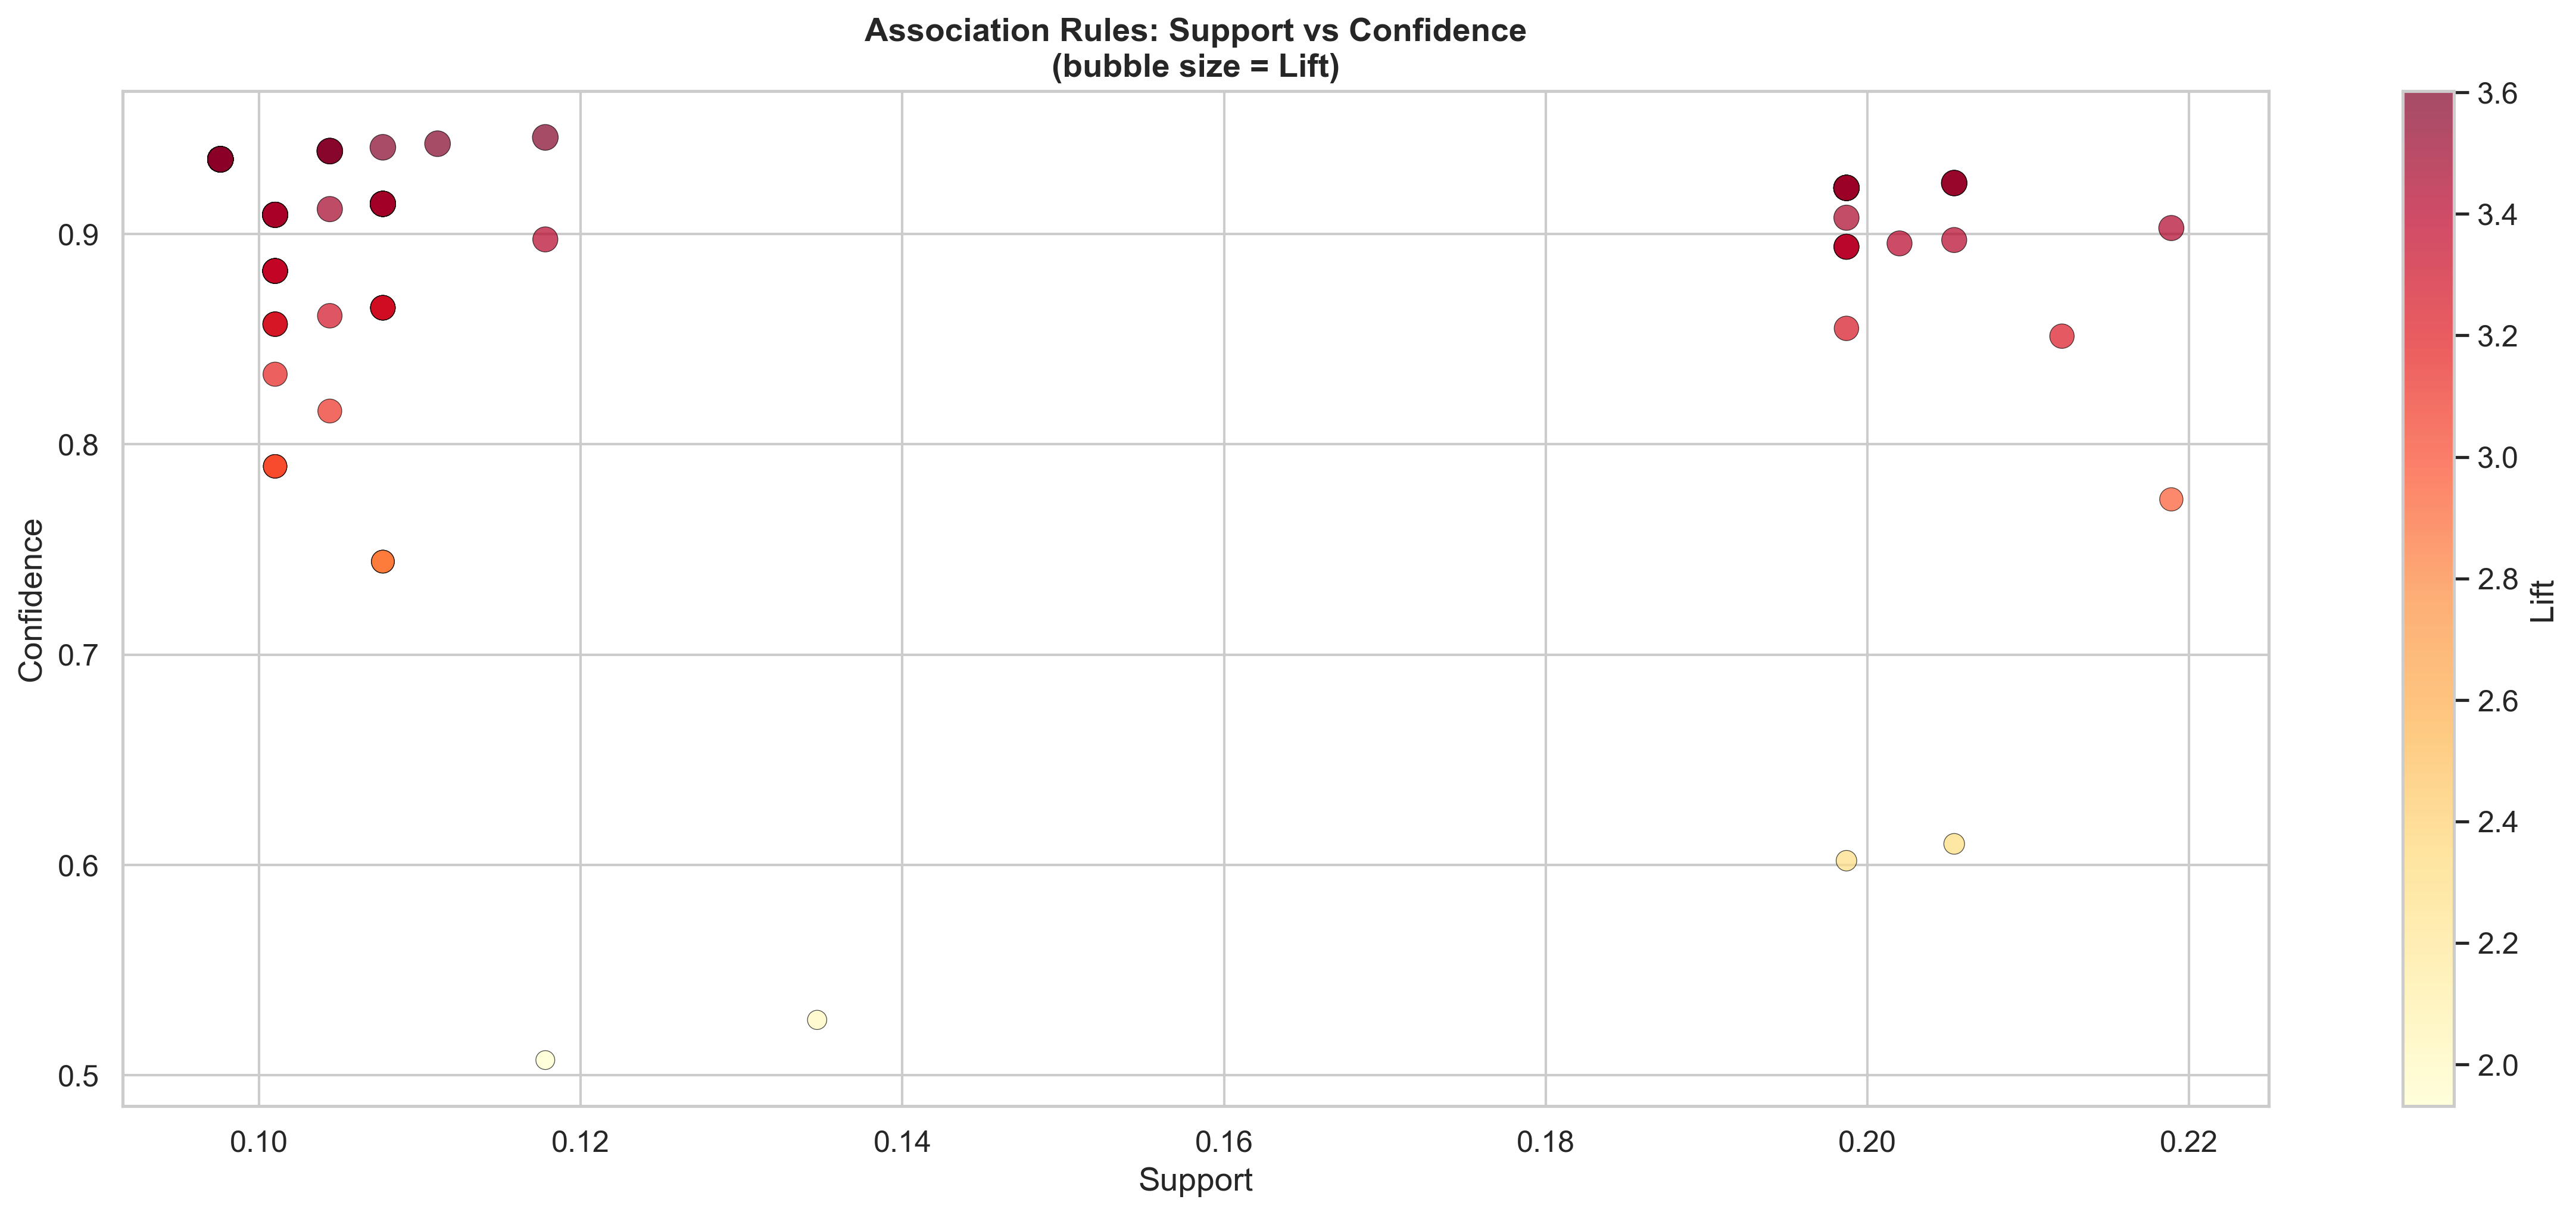

In [150]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7), dpi = 300) 
top_rules = rules_df.head(15).copy()

scatter = ax.scatter(rules_df['Support'], rules_df['Confidence'],
        c=rules_df['Lift'], cmap='YlOrRd',
        s=rules_df['Lift'] * 30, alpha=0.7,
        edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules: Support vs Confidence\n(bubble size = Lift)', fontweight='bold')

print("\nTop 10 Association Rules (→ Sleep Apnea):")
print(rules_df[['Antecedent', 'Support', 'Confidence', 'Lift']].head(10).to_string(index=False))

plt.tight_layout()
plt.show()